In [1]:
!date

Thu Sep 17 23:58:32 PDT 2026


In [2]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'
outdir = f'{projdir}/results/qc/data/qc18'
figdir = f'{projdir}/figures/pmds'

In [3]:
### per-haplotype solo-WCGW vs all-CpG table built in pmds/04a (qc15)
sw = pd.read_csv(f'{projdir}/results/qc/data/qc15/solo_wcgw_per_hap.tsv', sep='\t')
sw.head()

,sample,hap,all_common,all_constitutive,all_never,all_rare,all_variable,solo_common,solo_constitutive,solo_never,solo_rare,solo_variable,solo_depth,all_depth,chemistry
0,HG00097,1,58.529533,53.862091,72.599183,62.115643,59.196966,36.419562,30.475576,71.227528,45.709901,38.762747,40.751952,18.737092,R1041
1,HG00097,2,58.480651,53.881624,72.638200,62.119066,59.243505,36.348906,30.484991,71.278189,45.662002,38.807704,40.793199,18.756576,R1041
2,HG00099,1,64.228253,59.763380,74.169012,66.275400,64.583662,42.025647,35.549617,72.872575,49.542810,44.079088,37.322958,14.405632,R941
3,HG00099,2,64.260437,59.738728,74.185570,66.295786,64.664298,42.010403,35.502379,72.911088,49.636763,44.222730,37.408708,14.446842,R941
4,HG00126,1,63.391505,59.607205,73.004498,65.215599,63.613500,44.069989,38.215809,72.628523,51.424217,46.089322,34.412715,13.397293,R1041


In [4]:
sw.shape

(402, 15)

In [5]:
### hap1 vs hap2 concordance: is the clock a donor property (both haplotypes agree) or noisy per haplotype?
w = sw.pivot(index='sample', columns='hap', values=['solo_constitutive', 'all_constitutive', 'solo_depth', 'all_depth'])
pd.Series({k: np.corrcoef(w[(k, 1)], w[(k, 2)])[0, 1] for k in ['solo_constitutive', 'all_constitutive', 'solo_depth', 'all_depth']}).round(5)

solo_constitutive    0.99978
all_constitutive     0.99980
solo_depth           0.99958
all_depth            0.99966
dtype: float64

In [6]:
### donor level + a ratio metric: solo-WCGW mCG in domains relative to the donor's own never-domain solo-WCGW level
d = sw.groupby('sample')[['solo_constitutive', 'all_constitutive', 'solo_never', 'all_never', 'solo_depth', 'all_depth']].mean()
d['solo_ratio'] = d.solo_constitutive / d.solo_never
d['all_ratio'] = d.all_constitutive / d.all_never
cov = pd.read_csv(f'{projdir}/results/qc/data/qc17/donor_metrics_covariates.tsv', sep='\t').set_index('sample')
d = d.join(cov[['chemistry', 'superpopulation', 'sex', 'passage', 'established', 'hprc2_meth_qc_flag', 'xist_skew', 'log_ebv']], how='left')
d.head()

,solo_constitutive,all_constitutive,solo_never,all_never,solo_depth,all_depth,solo_ratio,all_ratio,chemistry,superpopulation,sex,passage,established,hprc2_meth_qc_flag,xist_skew,log_ebv
sample,,,,,,,,,,,,,,,,
HG00097,30.480284,53.871858,71.252859,72.618692,40.772575,18.746834,0.427776,0.741846,R1041,EUR,female,5.0,External,0.0,0.471476,-1.310384
HG00099,35.525998,59.751054,72.891832,74.177291,37.365833,14.426237,0.487380,0.805517,R941,EUR,female,5.0,External,0.0,0.781786,-0.808554
HG00126,38.245696,59.624904,72.655412,73.007974,34.409716,13.383070,0.526398,0.816690,R1041,EUR,male,5.0,External,0.0,NaN,-1.661712
HG00128,34.547575,55.680205,73.919260,73.655403,39.371686,17.975198,0.467369,0.755955,R1041,EUR,female,5.0,External,0.0,0.455455,-1.570553
HG00133,36.740552,58.985308,73.016942,73.461252,36.276389,14.475944,0.503178,0.802944,R1041,EUR,female,5.0,External,0.0,0.273500,-1.385520


In [7]:
d.shape

(201, 16)

In [8]:
### same covariate table as qc/02b: marginal R2 for chemistry, chemistry-partial R2 for the rest
metrics = ['solo_constitutive', 'all_constitutive', 'solo_depth', 'all_depth', 'solo_ratio', 'all_ratio']
covariates = ['chemistry', 'superpopulation', 'sex', 'passage', 'established', 'hprc2_meth_qc_flag', 'xist_skew', 'log_ebv']
categorical = {'chemistry', 'superpopulation', 'sex', 'established', 'hprc2_meth_qc_flag'}
rows = []
for y in metrics:
    for c in covariates:
        sub = d[list(dict.fromkeys([y, c, 'chemistry']))].dropna()
        term = f'C({c})' if c in categorical else c
        if c == 'chemistry':
            f = smf.ols(f'{y} ~ {term}', sub).fit(); rows.append({'metric': y, 'covariate': c, 'r2': f.rsquared, 'p': f.f_pvalue}); continue
        base = smf.ols(f'{y} ~ C(chemistry)', sub).fit(); both = smf.ols(f'{y} ~ C(chemistry) + {term}', sub).fit()
        rows.append({'metric': y, 'covariate': c, 'r2': (base.ssr - both.ssr) / base.ssr, 'p': both.compare_f_test(base)[1]})
a = pd.DataFrame(rows)
a.pivot(index='covariate', columns='metric', values='r2').reindex(covariates)[metrics].round(3)

metric,solo_constitutive,all_constitutive,solo_depth,all_depth,solo_ratio,all_ratio
covariate,,,,,,
chemistry,0.146,0.206,0.217,0.169,0.178,0.178
superpopulation,0.027,0.042,0.072,0.048,0.043,0.046
sex,0.000,0.000,0.012,0.001,0.002,0.000
passage,0.003,0.000,0.000,0.000,0.001,0.000
established,0.000,0.002,0.013,0.003,0.002,0.002
hprc2_meth_qc_flag,0.136,0.222,0.086,0.233,0.166,0.268
xist_skew,0.004,0.002,0.001,0.004,0.002,0.003
log_ebv,0.002,0.008,0.000,0.005,0.002,0.007


In [9]:
a.pivot(index='covariate', columns='metric', values='p').reindex(covariates)[metrics].applymap(lambda v: f'{v:.1e}')

metric,solo_constitutive,all_constitutive,solo_depth,all_depth,solo_ratio,all_ratio
covariate,,,,,,
chemistry,2.2e-08,1.3e-11,3.2e-12,1.4e-09,4.5e-10,4.5e-10
superpopulation,2.6e-01,8.2e-02,6.1e-03,5.0e-02,7.4e-02,6.2e-02
sex,7.6e-01,9.0e-01,1.3e-01,7.0e-01,5.7e-01,8.6e-01
passage,5.2e-01,8.1e-01,9.0e-01,8.7e-01,7.0e-01,8.8e-01
established,8.8e-01,5.5e-01,1.6e-01,5.3e-01,5.9e-01,5.7e-01
hprc2_meth_qc_flag,7.9e-08,1.8e-12,2.6e-05,4.5e-13,2.0e-09,4.1e-15
xist_skew,5.5e-01,6.7e-01,7.3e-01,5.3e-01,6.8e-01,6.1e-01
log_ebv,5.1e-01,2.3e-01,8.7e-01,3.2e-01,4.9e-01,2.4e-01


In [10]:
### spread: does the clock widen the continuum (coefficient of variation), within R9.4.1 only
r9 = d[d.chemistry == 'R941']
pd.Series({k: r9[k].std() / r9[k].mean() for k in metrics}).round(3)

solo_constitutive    0.160
all_constitutive     0.084
solo_depth           0.094
all_depth            0.228
solo_ratio           0.129
all_ratio            0.065
dtype: float64

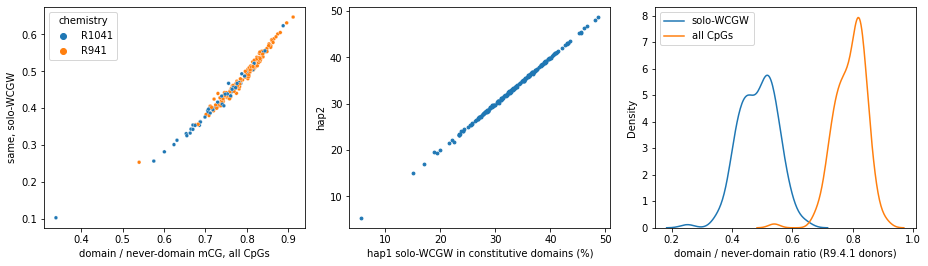

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
sns.scatterplot(data=d, x='all_ratio', y='solo_ratio', hue='chemistry', s=14, ax=axes[0])
axes[0].set_xlabel('domain / never-domain mCG, all CpGs'); axes[0].set_ylabel('same, solo-WCGW')
axes[1].scatter(w[('solo_constitutive', 1)], w[('solo_constitutive', 2)], s=8)
axes[1].set_xlabel('hap1 solo-WCGW in constitutive domains (%)'); axes[1].set_ylabel('hap2')
sns.kdeplot(data=r9, x='solo_ratio', ax=axes[2], label='solo-WCGW'); sns.kdeplot(data=r9, x='all_ratio', ax=axes[2], label='all CpGs')
axes[2].set_xlabel('domain / never-domain ratio (R9.4.1 donors)'); axes[2].legend()
plt.tight_layout()
plt.savefig(f'{figdir}/qc18_solo_wcgw_clock.png', dpi=150)

In [12]:
a.to_csv(f'{outdir}/solo_wcgw_covariate_r2.tsv', sep='\t', index=False)
d.to_csv(f'{outdir}/solo_wcgw_per_donor.tsv', sep='\t', float_format='%.5g')

In [13]:
!date

Thu Sep 17 23:58:37 PDT 2026
